# 03 Evaluation & Business Impact

**Goal**: Translate model metrics into business language.

The key insight: **threshold selection is a business decision, not an ML decision.**

The model outputs a probability (0–1). Where you cut that probability into 'fraud / not fraud'
depends on what your false positives and false negatives actually cost.

In fraud detection:
- **False Negative** (missed fraud): costs the full transaction amount ~$122 average
- **False Positive** (legit flagged): costs a review ~$2 + customer friction

The math is clear: we should lean toward catching fraud. Threshold < 0.5.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, roc_auc_score
)

RANDOM_STATE = 42
AVG_FRAUD_AMOUNT = 122.21
REVIEW_COST = 2.00

# Reload data and rebuild test set (same split as training notebook)
df = pd.read_csv('../data/creditcard.csv')
feature_cols = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount']
X = df[feature_cols].copy()
y = df['Class'].values

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

model = joblib.load('../models/fraud_model.joblib')
scaler = joblib.load('../models/scaler.joblib')

X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])
y_prob = model.predict_proba(X_test)[:, 1]

print('Model and test set loaded.')

Model and test set loaded.


## 1. AUPRC (The Right Metric)

For imbalanced datasets, the Precision-Recall curve tells us more than ROC.
ROC is optimistic on imbalanced data because it incorporates the large pool of true negatives.
AUPRC focuses purely on how well we identify the minority class.

AUPRC:          0.8668
AUROC:          0.9816
Random baseline AUPRC: 0.0017 (= fraud rate)
Lift over random: 504x


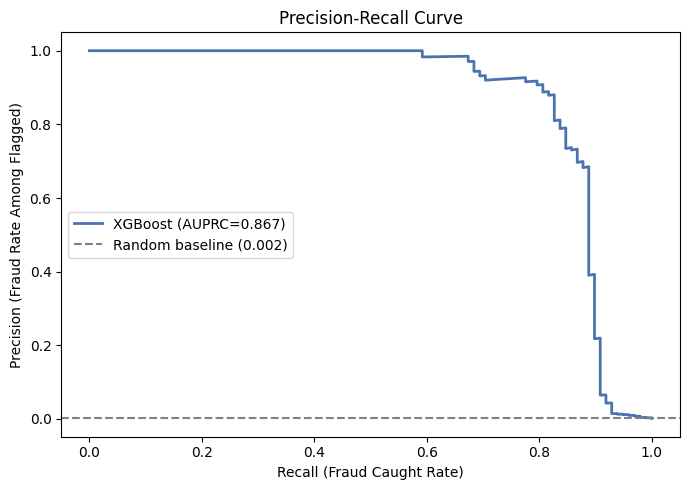

In [2]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
auprc = average_precision_score(y_test, y_prob)
auroc = roc_auc_score(y_test, y_prob)

print(f'AUPRC:          {auprc:.4f}')
print(f'AUROC:          {auroc:.4f}')
print(f'Random baseline AUPRC: {y_test.mean():.4f} (= fraud rate)')
print(f'Lift over random: {auprc / y_test.mean():.0f}x')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='#4C72B0', lw=2, label=f'XGBoost (AUPRC={auprc:.3f})')
ax.axhline(y_test.mean(), color='gray', linestyle='--', label=f'Random baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall (Fraud Caught Rate)')
ax.set_ylabel('Precision (Fraud Rate Among Flagged)')
ax.set_title('Precision-Recall Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Business Value by Threshold

For each possible threshold, we compute:
- How much fraud value is blocked (TP × avg_fraud_amount)
- How much review cost is incurred (FP × review_cost)
- Net business value saved

**The threshold with max net value is what goes into production, not 0.5.**

In [3]:
n_fraud_test = y_test.sum()
rows = []

for thresh, prec, rec in zip(thresholds, precision[:-1], recall[:-1]):
    tp = rec * n_fraud_test
    fp = (tp / prec - tp) if prec > 0 else 0
    fn = n_fraud_test - tp

    rows.append({
        'threshold': round(thresh, 3),
        'precision': round(prec, 4),
        'recall': round(rec, 4),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn),
        'value_blocked_usd': tp * AVG_FRAUD_AMOUNT,
        'review_costs_usd': fp * REVIEW_COST,
        'missed_fraud_usd': fn * AVG_FRAUD_AMOUNT,
        'net_value_usd': tp * AVG_FRAUD_AMOUNT - fp * REVIEW_COST
    })

biz_df = pd.DataFrame(rows)
best_row = biz_df.loc[biz_df['net_value_usd'].idxmax()]
best_threshold = best_row['threshold']

print(f'Best threshold by net business value: {best_threshold}')
print(f"\nAt threshold = {best_threshold}:")
print(f"  Precision: {best_row['precision']:.2%}")
print(f"  Recall:    {best_row['recall']:.2%}")
print(f"  Fraud value blocked: ${best_row['value_blocked_usd']:,.2f}")
print(f"  Review costs:        ${best_row['review_costs_usd']:,.2f}")
print(f"  Net value saved:     ${best_row['net_value_usd']:,.2f}")

Best threshold by net business value: 0.3840000033378601

At threshold = 0.3840000033378601:
  Precision: 68.50%
  Recall:    88.78%
  Fraud value blocked: $10,632.27
  Review costs:        $80.00
  Net value saved:     $10,552.27


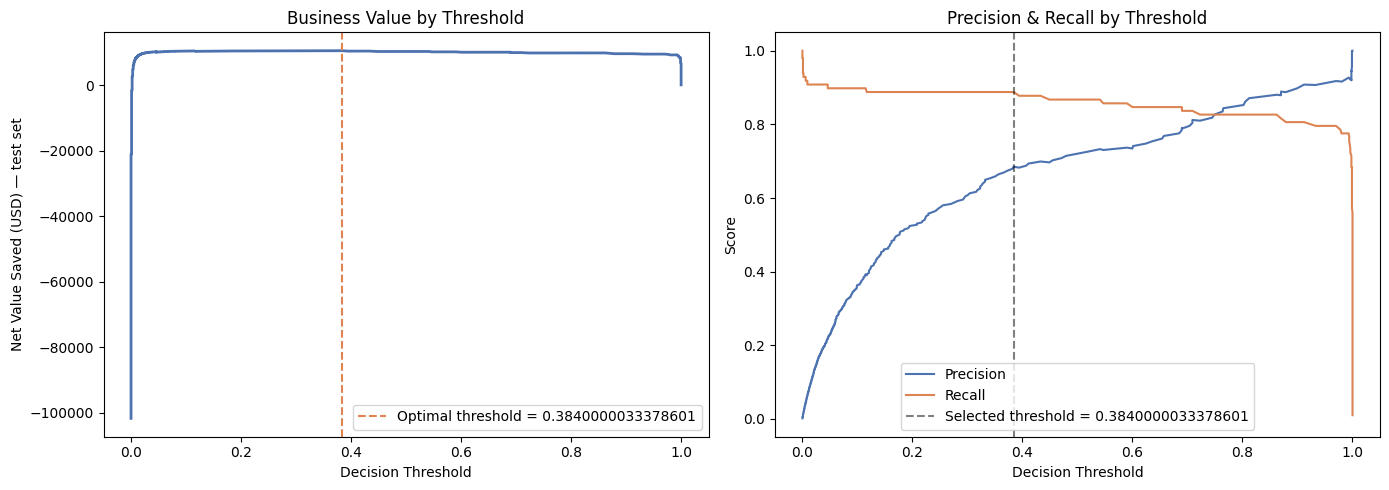

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Net value vs threshold
axes[0].plot(biz_df['threshold'], biz_df['net_value_usd'], color='#4C72B0', lw=2)
axes[0].axvline(best_threshold, color='#DD8452', linestyle='--', 
                label=f'Optimal threshold = {best_threshold}')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Net Value Saved (USD) — test set')
axes[0].set_title('Business Value by Threshold')
axes[0].legend()

# Plot 2: Precision vs Recall vs Threshold
axes[1].plot(biz_df['threshold'], biz_df['precision'], label='Precision', color='#4C72B0')
axes[1].plot(biz_df['threshold'], biz_df['recall'], label='Recall', color='#DD8452')
axes[1].axvline(best_threshold, color='black', linestyle='--', alpha=0.5,
                label=f'Selected threshold = {best_threshold}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall by Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Final Evaluation at Chosen Threshold

This is the number that goes in the README and in presentations.
Notice: we never say 'accuracy'. We say what it means in dollars.

In [5]:
y_pred = (y_prob >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print('='*55)
print(f'FINAL RESULTS @ threshold = {best_threshold}')
print('='*55)
print(f'\nConfusion Matrix:')
print(f'  True Positives  (fraud blocked):    {tp:>5,}')
print(f'  False Positives (legit flagged):     {fp:>5,}')
print(f'  False Negatives (fraud missed):      {fn:>5,}')
print(f'  True Negatives  (legit approved):    {tn:>5,}')

print(f'\nML Metrics:')
print(f'  AUPRC:     {auprc:.4f}')
print(f'  Precision: {tp/(tp+fp):.4f}')
print(f'  Recall:    {tp/(tp+fn):.4f}')

print(f'\nBusiness Metrics (test set ~ 20% of 2 days data):')
print(f'  Fraud value blocked:   ${tp * AVG_FRAUD_AMOUNT:>10,.2f}')
print(f'  Review costs incurred: ${fp * REVIEW_COST:>10,.2f}')
print(f'  Fraud value missed:    ${fn * AVG_FRAUD_AMOUNT:>10,.2f}')
print(f'  ─────────────────────────────────────')
print(f'  Net value protected:   ${tp * AVG_FRAUD_AMOUNT - fp * REVIEW_COST:>10,.2f}')

# Annualized estimate (2 days of data → 365 days)
annual_factor = 365 / 2
annual_net = (tp * AVG_FRAUD_AMOUNT - fp * REVIEW_COST) * annual_factor
print(f'\n  Annualized estimate:   ${annual_net:>10,.0f}')
print(f'  (extrapolated from 2-day dataset)')

print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

FINAL RESULTS @ threshold = 0.3840000033378601

Confusion Matrix:
  True Positives  (fraud blocked):       86
  False Positives (legit flagged):        40
  False Negatives (fraud missed):         12
  True Negatives  (legit approved):    56,824

ML Metrics:
  AUPRC:     0.8668
  Precision: 0.6825
  Recall:    0.8776

Business Metrics (test set ~ 20% of 2 days data):
  Fraud value blocked:   $ 10,510.06
  Review costs incurred: $     80.00
  Fraud value missed:    $  1,466.52
  ─────────────────────────────────────
  Net value protected:   $ 10,430.06

  Annualized estimate:   $ 1,903,486
  (extrapolated from 2-day dataset)

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.68      0.88      0.77        98

    accuracy                           1.00     56962
   macro avg       0.84      0.94      0.88     56962
weighted avg       1.00      1.00      1.00     56962



## 4. Probability Distribution — What the Model Sees

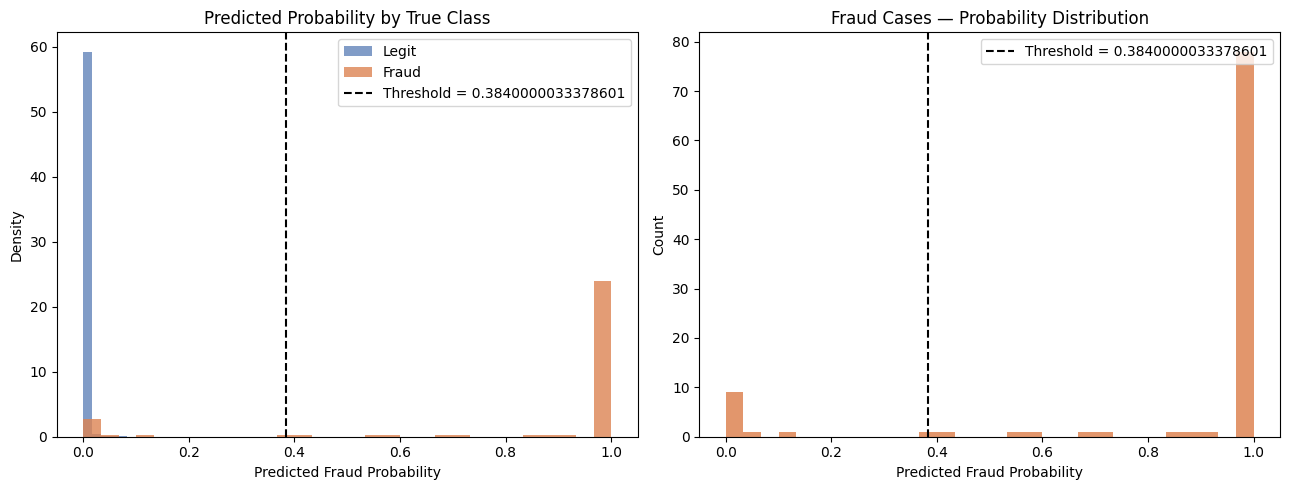

Fraud cases above threshold (caught): 86
Fraud cases below threshold (missed): 12


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of fraud probabilities by actual class
legit_probs = y_prob[y_test == 0]
fraud_probs = y_prob[y_test == 1]

axes[0].hist(legit_probs, bins=60, color='#4C72B0', alpha=0.7, label='Legit', density=True)
axes[0].hist(fraud_probs, bins=30, color='#DD8452', alpha=0.8, label='Fraud', density=True)
axes[0].axvline(best_threshold, color='black', linestyle='--', 
                label=f'Threshold = {best_threshold}')
axes[0].set_xlabel('Predicted Fraud Probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Predicted Probability by True Class')
axes[0].legend()

# Zoom in on fraud probabilities
axes[1].hist(fraud_probs, bins=30, color='#DD8452', alpha=0.85)
axes[1].axvline(best_threshold, color='black', linestyle='--',
                label=f'Threshold = {best_threshold}')
axes[1].set_xlabel('Predicted Fraud Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Fraud Cases — Probability Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Fraud cases above threshold (caught): {(fraud_probs >= best_threshold).sum()}')
print(f'Fraud cases below threshold (missed): {(fraud_probs < best_threshold).sum()}')